# AG-HYPOPT · Trial 19

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Eighteen trials are registered; cell 2 reports `phase = trials` (18/5), so proposals carry expected-improvement (ei) values. **Best = trial_08** (objective 0.1099). Picture (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_08 (0.1099, best):** travel 0.134.
- optimum cluster (0 div): trial_15 0.1103 (0.127), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_18 0.1121 (0.138), trial_09 0.1126 (0.123), trial_01 0.1127 (0.120), trial_14 0.1127 (0.140), trial_13 0.1132 (0.134).
- lower travel: trial_05 0.1135 (0.088), trial_07 0.1140 (0.097), trial_06 0.1188 (0.082).
- diverging: trial_17 0.1329 (0.088, 1nW T05), trial_10 0.1975 (0.099, 3nW T60), trial_03 0.1362 (0.074), trial_04 0.1418 (0.074), trial_02 0.1449 (0.264).

State of play: the optimum is a flat plateau at travel ~0.13 (the best eight within ~0.004, objectives 0.1099-0.1132); thirteen divergence-free runs all land in or near it. The low-travel region (<0.10) is consistently a little worse and is the only place divergences keep appearing (trials 03, 04, 10, 17). Residual errors unchanged: mid-T mu overshoot, 3nW high-T mu undershoot, low-T gamma under-recovery. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_19'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (18/5 trials)
ID |     ei | params
 1 | 3.6500 | {"gamma_anneal": 0.5606893887202747, "lr_gamma": 0.45759897683945605, "lr_mu": 0.08626558417414189, "mu_anneal": 0.35042016857710767}
 2 | 3.8623 | {"gamma_anneal": 0.465163394070567, "lr_gamma": 0.4585382156835163, "lr_mu": 0.1525604246991761, "mu_anneal": 0.36053038804378457}
 3 | 3.8664 | {"gamma_anneal": 0.5031128486636928, "lr_gamma": 0.45421042224925195, "lr_mu": 0.04937362089122459, "mu_anneal": 0.3481898421677238}
 4 | 3.1348 | {"gamma_anneal": 0.5010536550913764, "lr_gamma": 0.4054599035864032, "lr_mu": 0.10169393044432377, "mu_anneal": 0.3379775955902664}
 5 | 3.4653 | {"gamma_anneal": 0.7354705391999875, "lr_gamma": 0.40934751075431847, "lr_mu": 0.15392112066502886, "mu_anneal": 0.3528014757262198}
 6 | 2.9426 | {"gamma_anneal": 0.7478128011326597, "lr_gamma": 0.42913871779888485, "lr_mu": 0.16730393940539148, "mu_anneal": 0.35899881955681306}
 7 | 1.3083 | {"gamma_anneal": 0.7447069967159249, "lr_gamma": 0.735

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (18 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 3: ei 3.87 — `lr_mu=0.049`, `mu_anneal=0.348` (travel **0.041**, very low), `lr_gamma=0.454`, `gamma_anneal=0.503`.
- candidate 2: ei 3.86 — `lr_mu=0.153`, `mu_anneal=0.361` (travel **0.125**, at the optimum), `lr_gamma=0.459`, `gamma_anneal=0.465`.
- candidate 1: ei 3.65 — `lr_mu=0.086`, `mu_anneal=0.350` (travel 0.071), `lr_gamma=0.458`.
- candidate 5: ei 3.47 — `lr_mu=0.154`, `mu_anneal=0.353` (travel 0.127), `lr_gamma=0.409`, `gamma_anneal=0.735`.
- candidate 4: ei 3.13 — `lr_mu=0.102`, `mu_anneal=0.338` (travel 0.085), `lr_gamma=0.405`.

Candidates 3 (ei 3.87) and 2 (ei 3.86) are effectively tied at the top. Candidate 3 sits at travel 0.041 — far below anything tested, deep in the low-travel region that has produced every recent divergence (trials 03/04 at 0.074, trial_17 at 0.088, trial_10 at 0.099) and where even the divergence-free runs were a little worse. Candidate 2 sits exactly on the optimum (travel 0.125, between trial_01's 0.120 and trial_09's 0.123) with `lr_gamma=0.459`/`gamma_anneal=0.465` in the proven-safe range. Since the two ei values are within 0.01, the tied-but-much-safer candidate 2 makes clearly more sense: it samples the reliable optimum, whereas candidate 3 risks another divergence for a region already shown to be poor. The lower-ei candidates (1, 4) are also low-travel; candidate 5 duplicates the optimum but with a high `gamma_anneal=0.735` and lower ei.

I choose candidate 2 (2 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 2            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.465163394070567, 'lr_gamma': 0.4585382156835163, 'lr_mu': 0.1525604246991761, 'mu_anneal': 0.36053038804378457}
Running  1nW Trans05 ... 

μ 9.39 -> 10.32 | γ 8.5 -> 4.65 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 41.84 | γ 8.5 -> 6.22 | NLL 5.34


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 74.47 | γ 14.1 -> 14.41 | NLL 3.33


Running 3nW Trans100 ... 

μ 175.71 -> 107.09 | γ 14.1 -> 14.04 | NLL 3.42



Total: 8.7 min


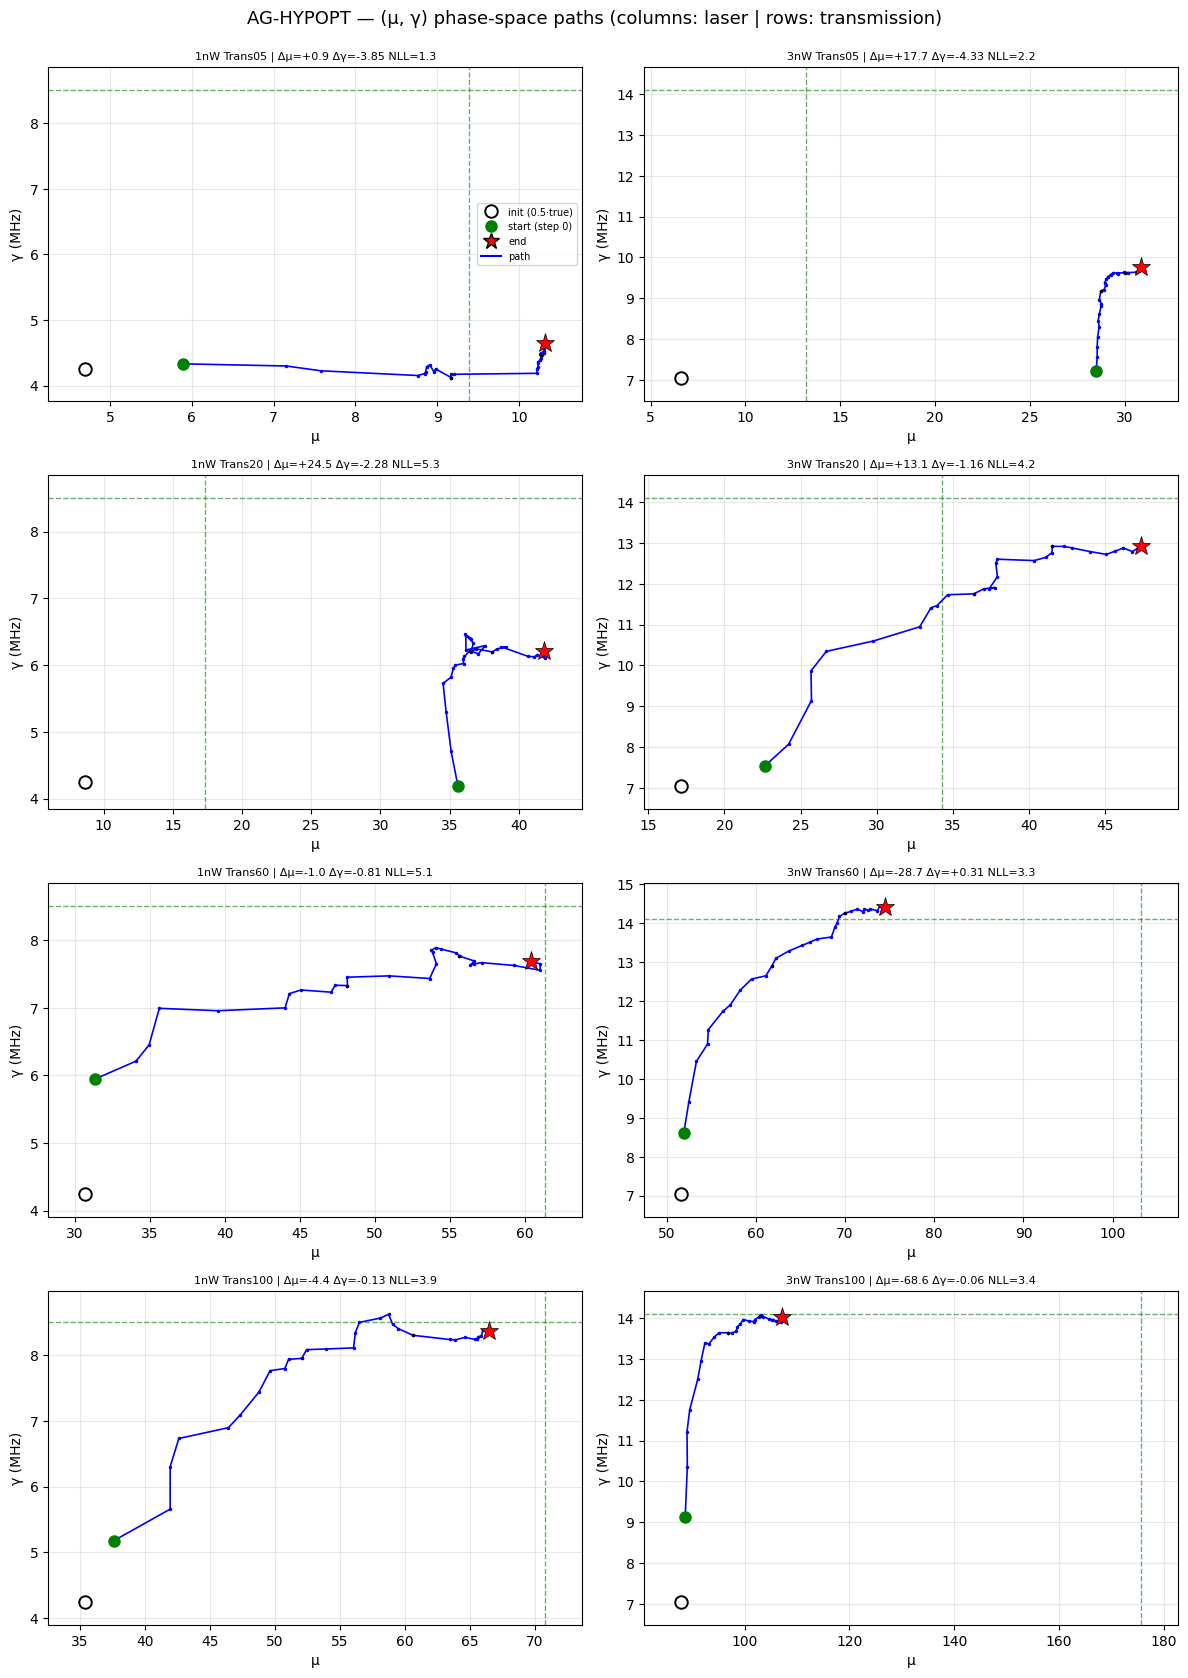

trial finished in 8.7 min
objective = 0.1135 ± 0.0823
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.32    +9.9 |     8.50    4.65   -45.3
1nW Trans20       17.32   41.84  +141.6 |     8.50    6.22   -26.8
1nW Trans60       61.37   60.40    -1.6 |     8.50    7.69    -9.5
1nW Trans100       70.82   66.46    -6.2 |     8.50    8.37    -1.5
3nW Trans05       13.20   30.87  +133.8 |    14.10    9.77   -30.7
3nW Trans20       34.28   47.40   +38.3 |    14.10   12.94    -8.2
3nW Trans60      103.20   74.47   -27.8 |    14.10   14.41    +2.2
3nW Trans100      175.71  107.09   -39.1 |    14.10   14.04    -0.5

weighted objective (T-graded, cap=1.0) = 0.1135 | diverged cells: 0
μ: RMSE 28.810 (rel 72.3%, bias -5.806) | γ: RMSE 2.260 (rel 22.0%, bias -1.539)


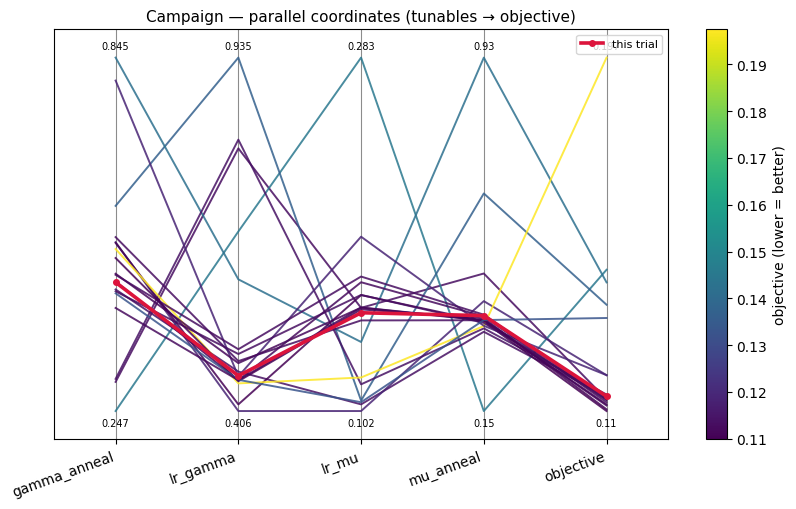

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 19 ran candidate 2 (ei=3.86; chosen over the essentially tied top-ei candidate 3, which sat at travel 0.041, deep in the low-travel divergence zone). Config: `lr_mu=0.1526`, `mu_anneal=0.3605` (effective mu travel 0.125), `lr_gamma=0.4585`, `gamma_anneal=0.4652`. It completed in 8.7 min with objective **0.1135 +/- 0.0823** and **0 diverged cells**. Ranking: trial_08 0.1099 < trial_15 0.1103 < trial_16 0.1112 < trial_12 0.1115 < trial_18 0.1121 < trial_09 0.1126 < trial_01 = trial_14 0.1127 < trial_13 0.1132 < trial_05 = **trial_19 0.1135** < ...

Aggregate accuracy: **mu rel-RMSE 72.3%** (RMSE 28.81, bias -5.81); **gamma rel-RMSE 22.0%** (RMSE 2.26, bias -1.54) — among the best gamma results of the campaign (trial_01 21.5%, trial_07 21.6%).

Per-cell relative errors:
- **mu:** 1nW T05 +9.9%, T20 +141.6%, T60 -1.6%, T100 -6.2% | 3nW T05 +133.8%, T20 +38.3%, T60 -27.8%, T100 -39.1%.
- **gamma:** 1nW T05 -45.3%, T20 -26.8%, T60 -9.5%, T100 -1.5% | 3nW T05 -30.7%, 3nW T20 -8.2%, T60 +2.2%, T100 -0.5%.

The safer of the two near-tied top candidates was the right call in stability terms: 0 diverged cells, good gamma everywhere, a solid 1nW high-T mu (T60 -1.6%, T100 -6.2%). The objective landed at 0.1135, exactly matching trial_05 and again inside the plateau. With this run the optimum/near-optimum region has 14 divergence-free samples spanning 0.1099-0.1188, and the top nine within ~0.004; the campaign has thoroughly mapped the surface and trial_08's 0.1099 is still the lowest.

**Summary:** Trial 19 (lr_mu=0.1526, mu_anneal=0.3605, lr_gamma=0.4585, gamma_anneal=0.4652): objective 0.1135 +/- 0.0823 with 0 diverged cells; a conservative optimum sample (travel 0.125) matched trial_05 exactly and added to the plateau, so trial_08 (0.1099) stays best.
**Key insight:** Choosing the safer of two near-tied EI candidates gave a clean, divergence-free run with excellent gamma (22.0%), but the plateau value is unchanged at ~0.11 - the schedule family has converged and trial_08 remains the best.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The campaign is firmly plateaued (14 divergence-free samples, best nine within 0.004). The two options to move beyond ~0.110 are structural, not hyperparameter: (i) the low-T gamma under-recovery and (ii) the mid-T mu overshoot; plus the sporadic divergence that still sometimes appears at low travel. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 19 (lr_mu=0.1526, mu_anneal=0.3605, lr_gamma=0.4585, gamma_anneal=0.4652): objective 0.1135 +/- 0.0823 with 0 diverged cells; a conservative optimum sample (travel 0.125) matched trial_05 exactly and added to the plateau, so trial_08 (0.1099) stays best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Choosing the safer of two near-tied EI candidates gave a clean, divergence-free run with excellent gamma (22.0%), but the plateau value is unchanged at ~0.11 - the schedule family has converged and trial_08 remains the best"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_19 | current best: trial_08


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_20.ipynb. Open it and follow its cells from the top.
